# Tarea 2

# Integrantes:
- Sofía Salinas Rico - ssalinas@unal.edu.co
- Camilo Chitivo Cerinza - cchitivo@unal.edu.co

Considere un tablero de ajedrez estándar de $8×8$
.

Las columnas del tablero se identifican mediante las letras 𝑎,𝑏,𝑐,𝑑,𝑒,𝑓,𝑔,ℎ

y las filas mediante los números $1,2,…,8.$

Por tanto, cada casilla se identifica mediante una letra y un número. 
El tablero queda identificado de la siguiente manera:

$$
\begin{array}{c|c|c|c|c|c|c|c|c}
\hline
8 & a8 & b8 & c8 & d8 & e8 & f8 & g8 & h8 \\ \hline
7 & a7 & b7 & c7 & d7 & e7 & f7 & g7 & h7 \\ \hline
6 & a6 & b6 & c6 & d6 & e6 & f6 & g6 & h6 \\ \hline
5 & a5 & b5 & c5 & d5 & e5 & f5 & g5 & h5 \\ \hline
4 & a4 & b4 & c4 & d4 & e4 & f4 & g4 & h4 \\ \hline
3 & a3 & b3 & c3 & d3 & e3 & f3 & g3 & h3 \\ \hline
2 & a2 & b2 & c2 & d2 & e2 & f2 & g2 & h2 \\ \hline
1 & a1 & b1 & c1 & d1 & e1 & f1 & g1 & h1 \\ \hline
  & a  & b  & c  & d  & e  & f  & g  & h  \\
\end{array}
$$


Considere un  caballo que se desplaza aleatoriamente sobre el tablero. Suponga que no hay otras piezas. El caballo realiza los movimientos usuales del ajedrez, se mueve formando una letra "L" mayúscula: avanza dos casillas en línea recta (en dirección vertical u horizontal) y luego da un giro de una casilla hacia un lado en ángulo recto. En cada movimiento, el caballo elige uniformemente al azar una de las casillas a las que puede desplazarse legalmente desde su posición actual.

Sea $X_n=$
posición del caballo en el 𝑛
-ésimo movimiento,  $𝑛=0,1,2,...$

De esta manera, $X=(X_n)_{n \geq 0}$
 es una Cadena de Markov.

# Ejercicios

## 1. Construcción de la cadena de Markov.

a) Describa el espacio de estados $S$ del proceso $X=(X_n)_{n \geq 0}$. ¿Cuántos estados tiene?

b) Para un estado $x\in S$, defina

$N(x) = \{y \in S : \text{el caballo puede pasar de } x \text{ a } y \text{ en un solo movimiento}\}$

$$|N(x)| = \operatorname{cardinal}(N(x))$$

Determine $N(x)$ y $|N(x)|$ para cada $x \in S$. Presente los resultados en una tabla que contenga $x$, $N(x)$, $|N(x)|$.

**c)** Teniendo en cuenta que el caballo elige moverse uniformemente entre todos los movimientos legales disponibles desde $x$, calcule las probabilidades de transición:

$$P_{xy} = P(X_{n+1} = y \mid X_n = x) = \begin{cases} \frac{1}{|N(x)|}, & y \in N(x) \\ 0, & y \notin N(x) \end{cases}$$

Ejemplo:

$$P_{a1,y} = \begin{cases} \frac{1}{2}, & y = b3, c2 \\ 0, & \text{caso contrario} \end{cases}$$

**d)** Presente las probabilidades de transición $P_{h8,y}$, $P_{g1,y}$, $P_{b7,y}$, $P_{f7,y}$, $P_{e5,y}$.

**e)** Fije un orden para las 64 casillas del tablero. Por ejemplo, puede utilizar:

$$a1, a2, \dots, a8, b1, b2, \dots, b8, \dots, h1, \dots, h8$$

Construya la matriz de transición $P = (P_{xy})_{x,y \in S}$.

La matriz puede ser construida utilizando un programa, incluya en el informe el código utilizado (o el enlace al código usado). No es necesario escribir todas sus entradas. Incluya en el informe, al menos, las filas de la matriz correspondientes a las casillas $g1$ y $h6$.

**f)** ¿La matriz $P$ es simétrica? Justifique su respuesta.


# Solución

## a)

Tradicionalmente los caballos inician en $b1, g1, b8$ y $g8$, supongamos que $X_0 = b1$, luego el espacio de estados $S$ se define como parejas $x,y$ tales que  $x\in \{ a,b,c,d,e,f,h \}$ y  $ 1< y \leq 8$

para saber cuantos estados tenemos hagamos una función que recorre el tablero.

In [1]:
def posibles_vecinos(x,y):
    return [(x+1,y+2),(x+1,y-2),(x-1,y+2),(x-1,y-2),(x+2,y+1),(x+2,y-1),(x-2,y+1), (x-2,y-1) ]
def vecinos_validos(x,y):
    return [(i,j) for (i,j) in posibles_vecinos(x,y) if i>=1 and i<=8 and j>=1 and j<=8]


vamos a utilizar dos aproach para este proyecto, uno iterativo por cada una de las casillas y otro recursivo

In [2]:
def todos_los_vecinos_validos_iterativo():
    return { (i,j):vecinos_validos(i,j) for i in range(1,9) for j in range(1,9) }

In [3]:
todos_los_vecinos_iterativo = todos_los_vecinos_validos_iterativo()
print(todos_los_vecinos_iterativo)

{(1, 1): [(2, 3), (3, 2)], (1, 2): [(2, 4), (3, 3), (3, 1)], (1, 3): [(2, 5), (2, 1), (3, 4), (3, 2)], (1, 4): [(2, 6), (2, 2), (3, 5), (3, 3)], (1, 5): [(2, 7), (2, 3), (3, 6), (3, 4)], (1, 6): [(2, 8), (2, 4), (3, 7), (3, 5)], (1, 7): [(2, 5), (3, 8), (3, 6)], (1, 8): [(2, 6), (3, 7)], (2, 1): [(3, 3), (1, 3), (4, 2)], (2, 2): [(3, 4), (1, 4), (4, 3), (4, 1)], (2, 3): [(3, 5), (3, 1), (1, 5), (1, 1), (4, 4), (4, 2)], (2, 4): [(3, 6), (3, 2), (1, 6), (1, 2), (4, 5), (4, 3)], (2, 5): [(3, 7), (3, 3), (1, 7), (1, 3), (4, 6), (4, 4)], (2, 6): [(3, 8), (3, 4), (1, 8), (1, 4), (4, 7), (4, 5)], (2, 7): [(3, 5), (1, 5), (4, 8), (4, 6)], (2, 8): [(3, 6), (1, 6), (4, 7)], (3, 1): [(4, 3), (2, 3), (5, 2), (1, 2)], (3, 2): [(4, 4), (2, 4), (5, 3), (5, 1), (1, 3), (1, 1)], (3, 3): [(4, 5), (4, 1), (2, 5), (2, 1), (5, 4), (5, 2), (1, 4), (1, 2)], (3, 4): [(4, 6), (4, 2), (2, 6), (2, 2), (5, 5), (5, 3), (1, 5), (1, 3)], (3, 5): [(4, 7), (4, 3), (2, 7), (2, 3), (5, 6), (5, 4), (1, 6), (1, 4)], (3, 6

In [4]:
inicial = (2,1)
todos_los_vecinos_recursivos = {}
def todos_los_vecinos_validos_recursivo(x,y):
    nuevos_vecinos = vecinos_validos(x,y)
    todos_los_vecinos_recursivos[(x,y)] = nuevos_vecinos
    for vecino in nuevos_vecinos:
        if vecino not in todos_los_vecinos_recursivos:
            todos_los_vecinos_validos_recursivo(vecino[0],vecino[1])

In [5]:
todos_los_vecinos_validos_recursivo(inicial[0],inicial[1])
print(todos_los_vecinos_recursivos)


{(2, 1): [(3, 3), (1, 3), (4, 2)], (3, 3): [(4, 5), (4, 1), (2, 5), (2, 1), (5, 4), (5, 2), (1, 4), (1, 2)], (4, 5): [(5, 7), (5, 3), (3, 7), (3, 3), (6, 6), (6, 4), (2, 6), (2, 4)], (5, 7): [(6, 5), (4, 5), (7, 8), (7, 6), (3, 8), (3, 6)], (6, 5): [(7, 7), (7, 3), (5, 7), (5, 3), (8, 6), (8, 4), (4, 6), (4, 4)], (7, 7): [(8, 5), (6, 5), (5, 8), (5, 6)], (8, 5): [(7, 7), (7, 3), (6, 6), (6, 4)], (7, 3): [(8, 5), (8, 1), (6, 5), (6, 1), (5, 4), (5, 2)], (8, 1): [(7, 3), (6, 2)], (6, 2): [(7, 4), (5, 4), (8, 3), (8, 1), (4, 3), (4, 1)], (7, 4): [(8, 6), (8, 2), (6, 6), (6, 2), (5, 5), (5, 3)], (8, 6): [(7, 8), (7, 4), (6, 7), (6, 5)], (7, 8): [(8, 6), (6, 6), (5, 7)], (6, 6): [(7, 8), (7, 4), (5, 8), (5, 4), (8, 7), (8, 5), (4, 7), (4, 5)], (5, 8): [(6, 6), (4, 6), (7, 7), (3, 7)], (4, 6): [(5, 8), (5, 4), (3, 8), (3, 4), (6, 7), (6, 5), (2, 7), (2, 5)], (5, 4): [(6, 6), (6, 2), (4, 6), (4, 2), (7, 5), (7, 3), (3, 5), (3, 3)], (4, 2): [(5, 4), (3, 4), (6, 3), (6, 1), (2, 3), (2, 1)], (3,

como vamos a confiar en los recursivos, veamos cuantos vecinos totales obtuvimos

In [6]:
print(len(todos_los_vecinos_recursivos.keys()))

64


entonces todas las posiciones del tablero de ajedrez se pueden alcanzar desde la posición inicial (2,1) usando movimientos de caballo.

## b)

dado que ya tenemos estos resultados, podemos generar la tabla.

In [7]:
map_letras = {1:'a', 2:'b', 3:'c', 4:'d', 5:'e', 6:'f', 7:'g', 8:'h'}
lambda_map = lambda x: (map_letras[x[0]]+str(x[1]))
resultados_crudos = [(x, N_x, len(N_x)) for x, N_x in todos_los_vecinos_iterativo.items()]
resultados = [(lambda_map(x), [lambda_map(y) for y in N_x], len_N_x) for x, N_x, len_N_x in resultados_crudos]


In [8]:
from tabulate import tabulate

print(tabulate(resultados, headers=["x", "N(x)","|N(x)|"], tablefmt="github") )


| x   | N(x)                                             |   |N(x)| |
|-----|--------------------------------------------------|----------|
| a1  | ['b3', 'c2']                                     |        2 |
| a2  | ['b4', 'c3', 'c1']                               |        3 |
| a3  | ['b5', 'b1', 'c4', 'c2']                         |        4 |
| a4  | ['b6', 'b2', 'c5', 'c3']                         |        4 |
| a5  | ['b7', 'b3', 'c6', 'c4']                         |        4 |
| a6  | ['b8', 'b4', 'c7', 'c5']                         |        4 |
| a7  | ['b5', 'c8', 'c6']                               |        3 |
| a8  | ['b6', 'c7']                                     |        2 |
| b1  | ['c3', 'a3', 'd2']                               |        3 |
| b2  | ['c4', 'a4', 'd3', 'd1']                         |        4 |
| b3  | ['c5', 'c1', 'a5', 'a1', 'd4', 'd2']             |        6 |
| b4  | ['c6', 'c2', 'a6', 'a2', 'd5', 'd3']             |        6 |
| b5  | ['c7', 'c3',

## c)

Para responder los problemas c) y d) construimos un generador de código tex 

In [9]:
from IPython.display import Math, Latex


def probabilidad_de_transicion(x, N_x, len_N_x):
  elementos_y = ", ".join(N_x)

  # Construimos la cadena de LaTeX
  latex_code = (
      rf"P_{{{x},y}} = \begin{{cases}} \frac{{1}}{{{len_N_x}}}, & y ="
      rf" {elementos_y} \\ 0, & \text{{caso contrario}} \end{{cases}}"
  )

  display(Latex(rf"${latex_code}$"))

In [10]:
probabilidad_de_transicion(resultados[0][0], resultados[0][1], resultados[0][2])

<IPython.core.display.Latex object>

In [11]:
for x, N_x,len_N_x in resultados:
    probabilidad_de_transicion(x, N_x, len_N_x)

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

...

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

## d)

Ahora hagamos las especificas 

In [12]:
# $P_{h8,y}$, $P_{g1,y}$, $P_{b7,y}$, $P_{f7,y}$, $P_{e5,y}$.
#h = 8, 7*8 + 8 -1  = 63
#g = 7, 6*8 + 1 -1  = 48
#b = 2, 1*8 + 7 -1  = 14
#f = 6, 5*8 + 7 -1  = 46
#e = 5, 4*8 + 5 -1  = 36
probabilidad_de_transicion(resultados[63][0], resultados[63][1], resultados[63][2])
probabilidad_de_transicion(resultados[48][0], resultados[48][1], resultados[48][2])
probabilidad_de_transicion(resultados[14][0], resultados[14][1], resultados[14][2])
probabilidad_de_transicion(resultados[46][0], resultados[46][1], resultados[46][2])
probabilidad_de_transicion(resultados[36][0], resultados[36][1], resultados[36][2])

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

## e)

In [13]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [14]:
matriz_de_transicion = np.zeros((64,64))
for x, N_x, len_N_x in resultados_crudos:
    index_x = (x[0]-1)*8 + x[1] - 1
    for vecino in N_x:
        index_vecino = (vecino[0]-1)*8 + vecino[1] - 1
        matriz_de_transicion[index_x][index_vecino] = 1/len_N_x
    

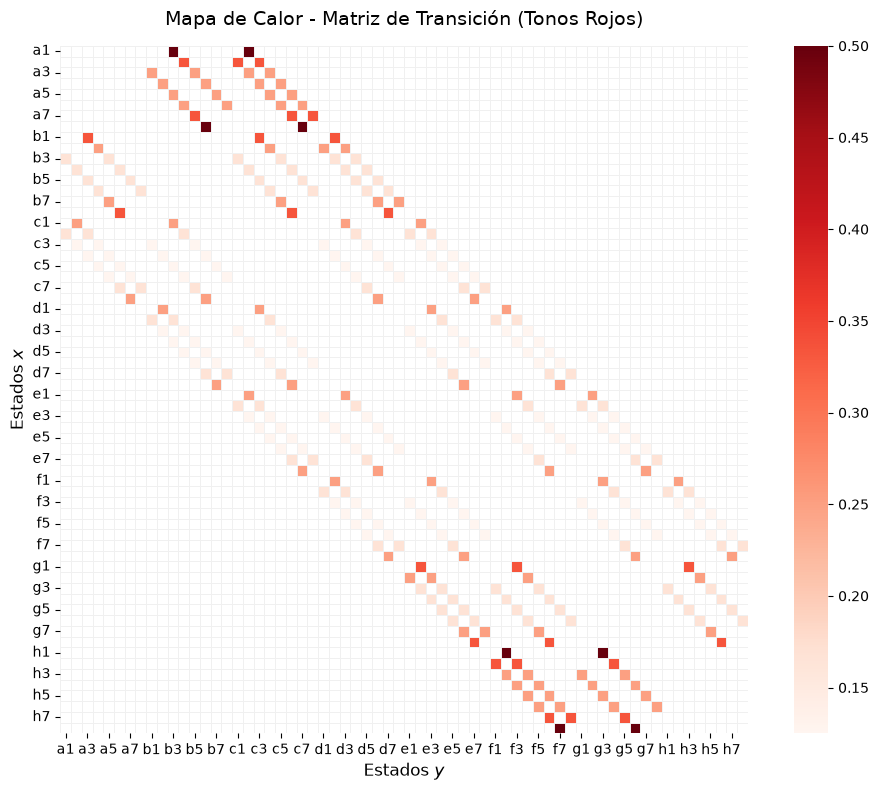

In [15]:
filas_x = [item[0] for item in resultados]
columnas_y = [y for item in resultados for y in item[1]]
todos_los_estados = sorted(list(set(filas_x + columnas_y)))

# 2. Crear el DataFrame con ceros
matriz = pd.DataFrame(0.0, index=todos_los_estados, columns=todos_los_estados)

# 3. Rellenar las probabilidades P(x, y) = 1 / |N(x)|
for x, N_x, len_N_x in resultados:
  probabilidad = 1.0 / len_N_x
  for y in N_x:
    if y in matriz.columns:
      matriz.loc[x, y] = probabilidad

# 4. Reemplazar los ceros por NaN para que aparezcan en blanco
matriz_limpia = matriz.replace(0.0, np.nan)

# 5. Configurar y graficar el mapa de calor
plt.figure(figsize=(10, 8))
sns.heatmap(
    matriz_limpia,
    annot=False,  # Sin números dentro de las celdas
    cmap="Reds",  # Paleta de tonos rojos
    cbar=True,  # Barra de color lateral
    square=True,  # Celdas cuadradas
    linewidths=0.5,  # Líneas divisorias para notar la cuadrícula
    linecolor="#f0f0f0",  # Líneas sutiles
    mask=matriz_limpia.isnull(),  # Fuerza a que los NaN (ceros) se queden blancos
)

plt.title(
    "Mapa de Calor - Matriz de Transición (Tonos Rojos)", fontsize=14, pad=15
)
plt.xlabel("Estados $y$", fontsize=12)
plt.ylabel("Estados $x$", fontsize=12)
plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

Ahora veamos la matriz de transición con los porcentajes coorespondientes

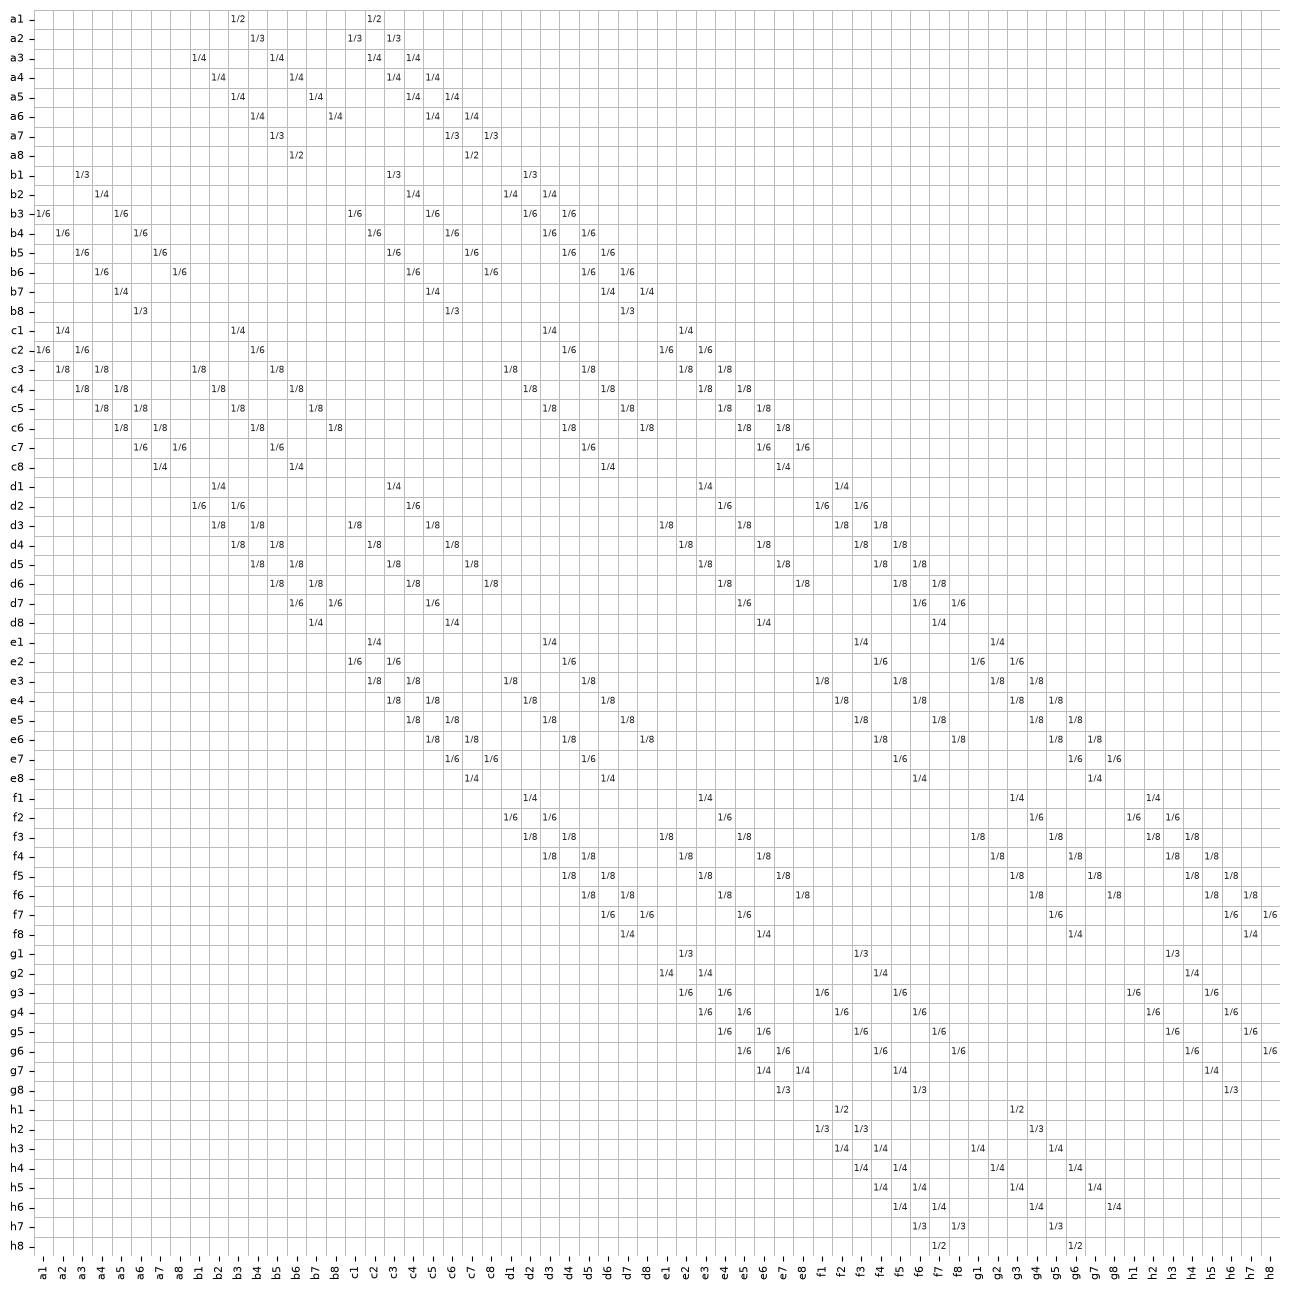

In [16]:
def pos_str(p):
  return f"{'abcdefgh'[p[0]-1]}{p[1]}" if isinstance(p, tuple) else str(p)


datos = resultados_crudos

estados = [pos_str(item[0]) for item in datos]
m_num = pd.DataFrame(0.0, index=estados, columns=estados)
m_txt = pd.DataFrame("", index=estados, columns=estados)

for x, N_x, n_len in datos:
  origen = pos_str(x)
  for y in N_x:
    destino = pos_str(y)
    m_txt.loc[origen, destino] = f"1/{n_len}"
    m_num.loc[origen, destino] = 1 / n_len

plt.figure(figsize=(15, 13))
sns.heatmap(
    m_num,
    annot=m_txt,
    fmt="",
    cmap=["white"],
    cbar=False,
    square=True,
    linewidths=0.5,
    linecolor="#bbb",
    annot_kws={"size": 6.5},
)

plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

## f)

Ahora bien, ¿Es simétrica esta matriz de transición?, 
A pesar de que si existe una probabilidad de transición de un estado x a un estado y, entonces también existe una probabilidad de transición de y a x y de que moverse en caballo es reversible, que sea simetrica también es la cantidad de vecinos que tiene cada estado.
Si tuvieramos un tablero infinito, entonces la matriz de transición sería simétrica, ya que todos los estados tendrían 8 vecinos. 
Sin embargo, en un tablero finito, los estados en los bordes y esquinas tienen menos vecinos, lo que rompe la simetría de la matriz de transición.

Tan simple como ver que $(a3,b1) \neq (b1,a3)$ en nuestra matriz de transición. pues $a3$ tiene $4$ vecinos y $b1$ solo tiene 3.

## 2.  Calcular

$P(X_1=c2)$,  $P(X_1=c2,X_2=d4,X_3=e6,X_4=c7)$,  $P(X_3=e2,X_2=d4∣X_1=b3)$,  $P(X_{n+2}=e3∣X_n=a3)$.

# Solución

# 3. Tablero

a) Dibuje un tablero de ajedrez de $8\times 8$.


b) Pinte inicialmente la casilla $a1$.

c) Pinte todas las casillas a las que el caballo puede llegar desde $a1$, **en un movimiento**.

d) A partir de las casillas obtenidas en el paso anterior, pinte las casillas que pueden ser alcanzadas en un movimiento.

e) Continúe sucesivamente este procedimiento. Si una casilla ya fue pintada en un paso anterior, no es necesario volver a pintarla.  

f) Continúe el procedimiento hasta que no aparezcan nuevas casillas.
    ¿Cuántas de las 64 casillas del tablero fueron pintadas?
    ¿Cuáles no fueron pintadas? ¿Qué permite concluir el procedimiento anterior?

g) ¿se tendrán resultados similares si el caballo inicia en la casilla $d5$? Justifique su respuesta.

# Solución

## a) hasta f)

In [17]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from PIL import Image
from pathlib import Path
import imageio.v2 as imageio
from IPython.display import Video

In [18]:
class ChessBoard:
    def __init__(self, marked_squares=None):
        """
        marked_squares:
        [
            (columna, fila, valor),
            ...
        ]
        """
        self.marked_squares = marked_squares or []
        self.files = "abcdefgh"

    def _validate_square(self, square):
        if not isinstance(square, tuple) or len(square) != 3:
            raise ValueError(
                f"Formato inválido: {square}. "
                "Debe ser (columna, fila, valor)"
            )

        col, row, _ = square

        if not isinstance(col, int) or not isinstance(row, int):
            raise ValueError(f"Columna y fila deben ser enteros: {square}")

        if not (1 <= col <= 8 and 1 <= row <= 8):
            raise ValueError(f"Casilla fuera del tablero: {square}")

    def draw(self, save_path=None):
        fig, ax = plt.subplots(figsize=(8, 8))

        # Dibujar tablero
        for row in range(8):
            for col in range(8):
                color = "white" if (row + col) % 2 == 0 else "gray"

                ax.add_patch(
                    Rectangle(
                        (col, row),
                        1,
                        1,
                        facecolor=color,
                        edgecolor="black"
                    )
                )

        # Marcar casillas y escribir valor
        for square in self.marked_squares:
            self._validate_square(square)

            col, row, value = square

            x = col - 1
            y = row - 1

            # Marca
            ax.add_patch(
                Rectangle(
                    (x, y),
                    1,
                    1,
                    facecolor="red",
                    alpha=0.6
                )
            )

            # Valor
            ax.text(
                x + 0.5,
                y + 0.5,
                str(value),
                ha="center",
                va="center",
                fontsize=14,
                fontweight="bold",
                color="white"
            )

        # Numeración
        ax.set_xticks([i + 0.5 for i in range(8)])
        ax.set_xticklabels(self.files)

        ax.set_yticks([i + 0.5 for i in range(8)])
        ax.set_yticklabels(range(1, 9))

        ax.set_xlim(0, 8)
        ax.set_ylim(0, 8)
        ax.set_aspect("equal")

        if save_path:
            plt.savefig(save_path, bbox_inches="tight")

        plt.show()


In [19]:
def posibles_vecinos(x,y):
    return [(x+1,y+2),(x+1,y-2),(x-1,y+2),(x-1,y-2),(x+2,y+1),(x+2,y-1),(x-2,y+1), (x-2,y-1) ]
def vecinos_validos(x,y):
    return [(i,j) for (i,j) in posibles_vecinos(x,y) if i>=1 and i<=8 and j>=1 and j<=8]

In [20]:
def marcar_movimientos(lista: list[tuple], lista_marca: list[tuple], marca: str):
    new = []
    for x, y in lista:
        vecinos = vecinos_validos(x, y)
        for v in vecinos:
            if v not in lista+new:
                new.append(v)
    new_marca = [(i, j, marca) for i, j in new]
    lista += new
    lista_marca += new_marca
    return lista, lista_marca


In [21]:
def crear_tablero(x, y):
    path = f"./images/{x}_{y}"
    Path(path).mkdir(exist_ok=True)
    
    marca = 0
    lista = [(x, y)]
    lista_marca = [(x, y, str(marca))]
    board = ChessBoard(lista_marca)
    board.draw(f"{path}/tablero_{marca}.png")

    marca = 1
    m, n = 0 , -1
    while n != m:
        n = len(lista)
        lista, lista_marca = marcar_movimientos(lista, lista_marca, str(marca))
        m = len(lista)
        if n != m:
            board = ChessBoard(lista_marca)
            board.draw(f"{path}/tablero_{marca}.png")
            marca += 1


In [22]:
from PIL import Image
from pathlib import Path
from IPython.display import display, Image as IPImage


class GifGenerator:
    def __init__(self, folder_path: str):
        self.folder = Path(folder_path)

    def generate(
        self,
        output_path="tablero.gif",
        duration=2000,
        loop=0
    ):
        image_paths = sorted(
            list(self.folder.glob("*.png")) +
            list(self.folder.glob("*.jpg")) +
            list(self.folder.glob("*.jpeg"))
        )

        if not image_paths:
            raise ValueError("No se encontraron imágenes en la carpeta.")

        images = [
            Image.open(path).convert("RGB")
            for path in image_paths
        ]

        images[0].save(
            output_path,
            save_all=True,
            append_images=images[1:],
            duration=duration,
            loop=loop
        )

        # Mostrar GIF en el notebook
        display(IPImage(filename=output_path))

## f)

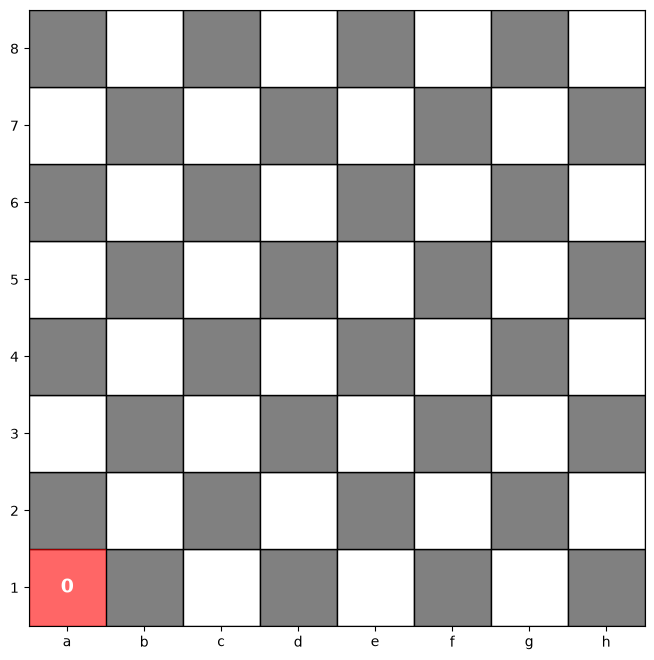

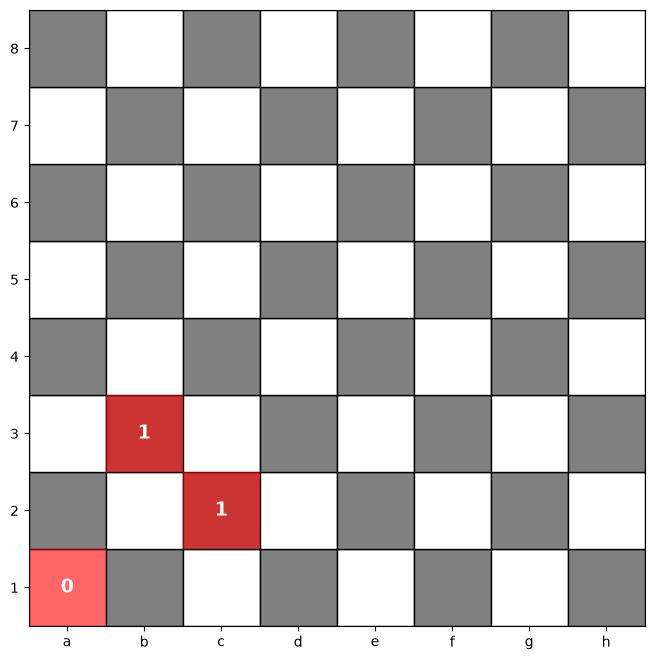

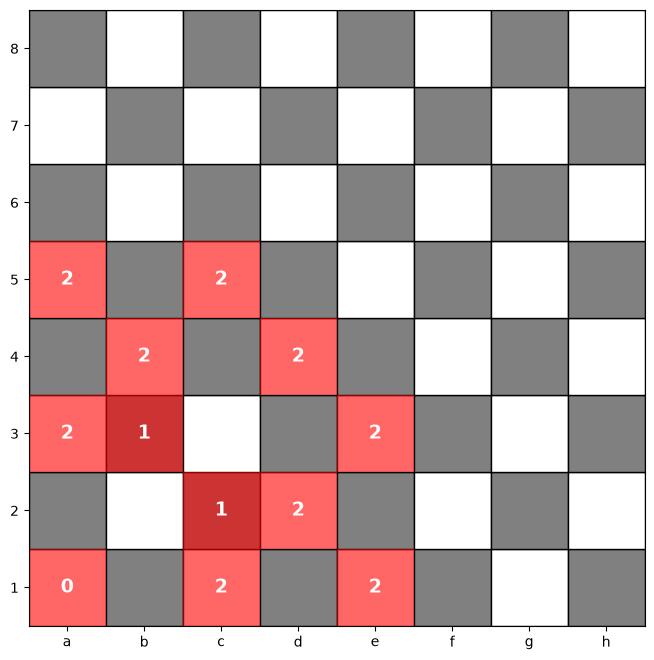

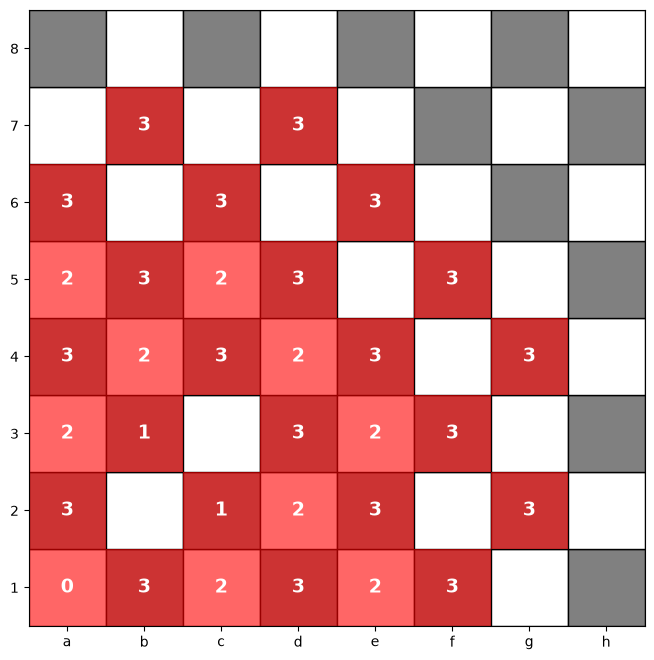

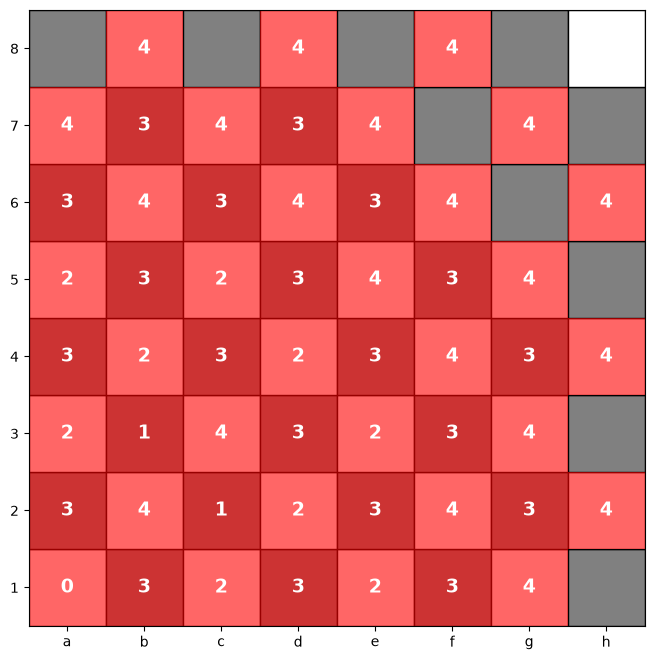

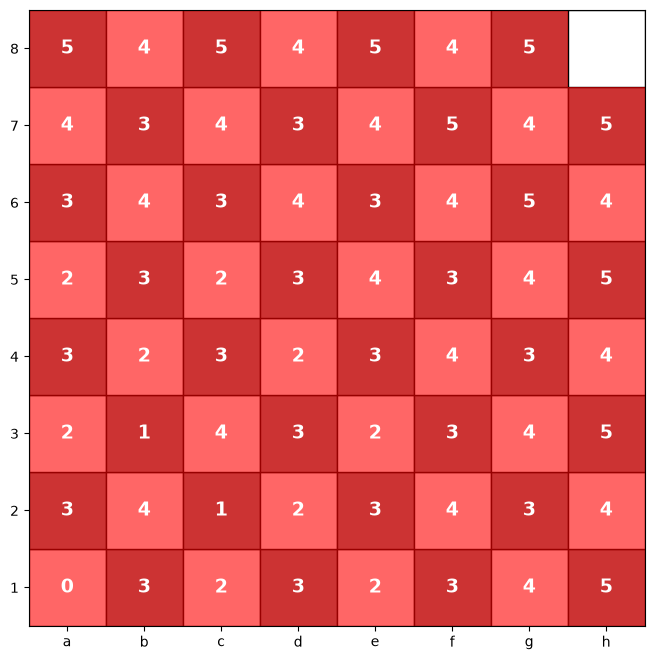

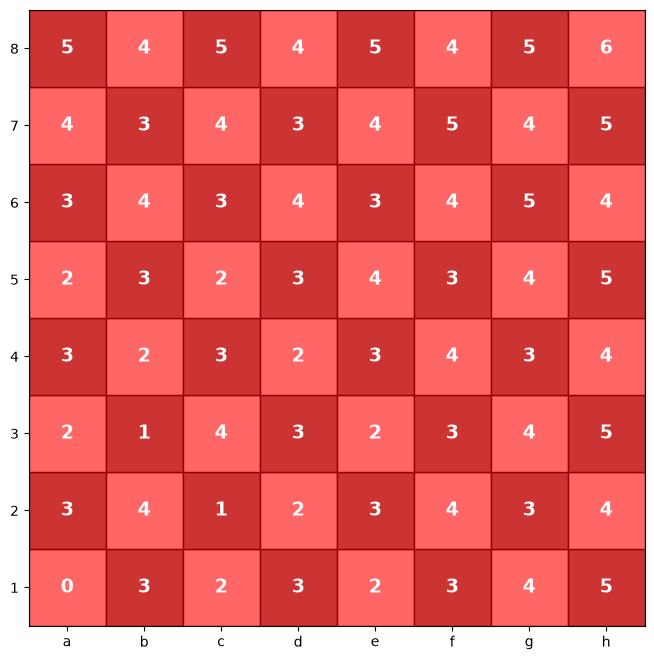

In [23]:
x, y = 1, 1
crear_tablero(x, y)

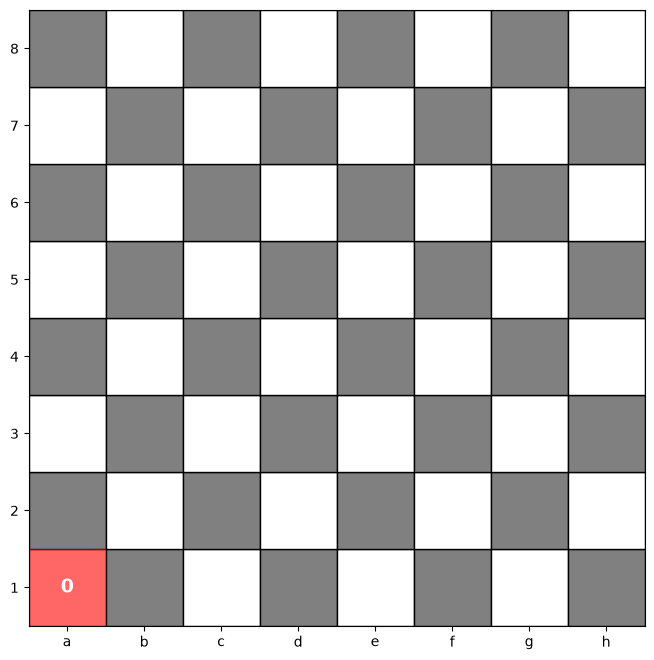

In [24]:
path = f"./images/{x}_{y}"
generator = GifGenerator(path)

generator.generate(
    output_path=f"./gif/evolucion_tablero_{x}_{y}.gif",
    duration=1500
)

¿Cuántas de las 64 casillas del tablero fueron pintadas?

- Fueron pintadas todas las 64 casillas.

¿Cuáles no fueron pintadas? 

- Ninguna quedó sin pintar

¿Qué permite concluir el procedimiento anterior?

- Que desde $a1$ el caballo puede recorrer todas y cada una de las casillas.

## g)

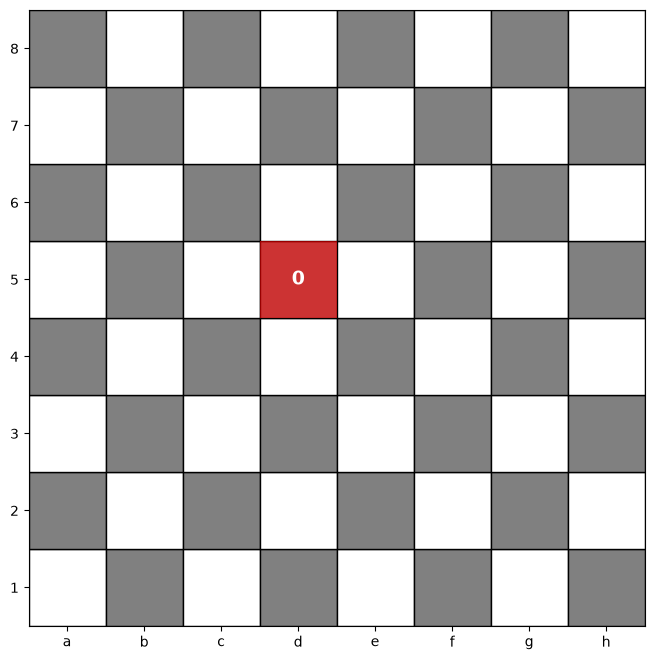

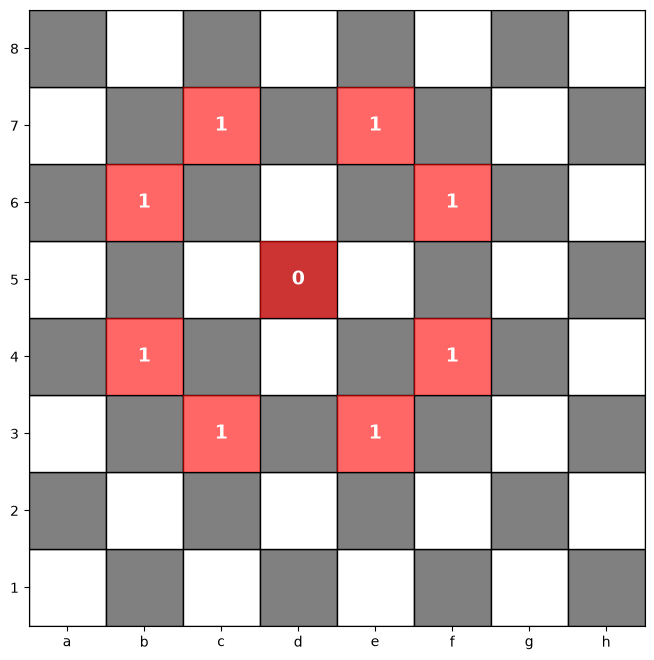

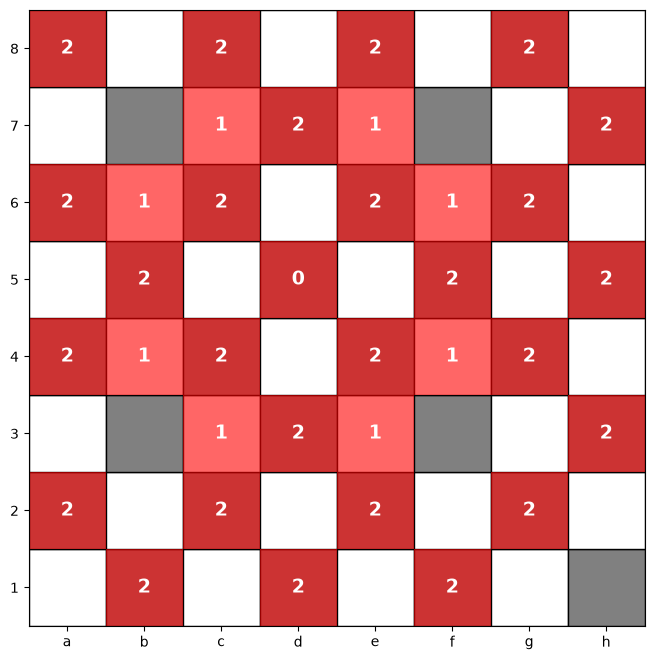

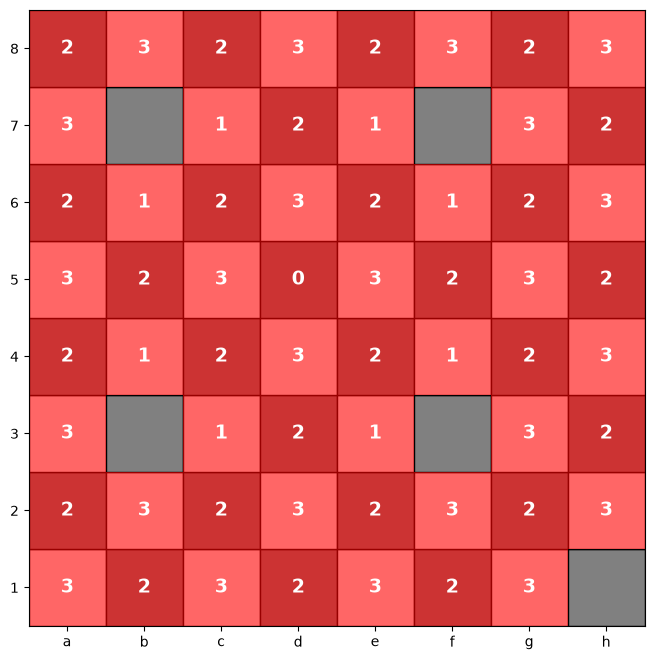

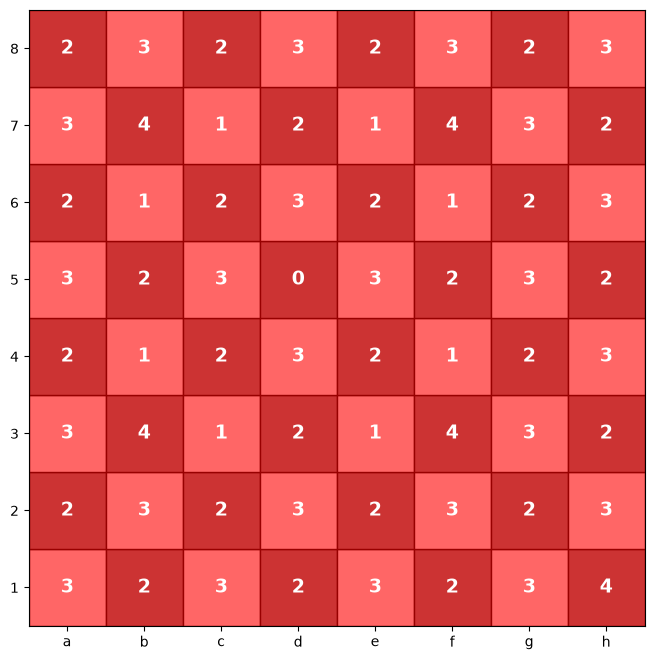

In [25]:
x, y = 4, 5
crear_tablero(x, y)

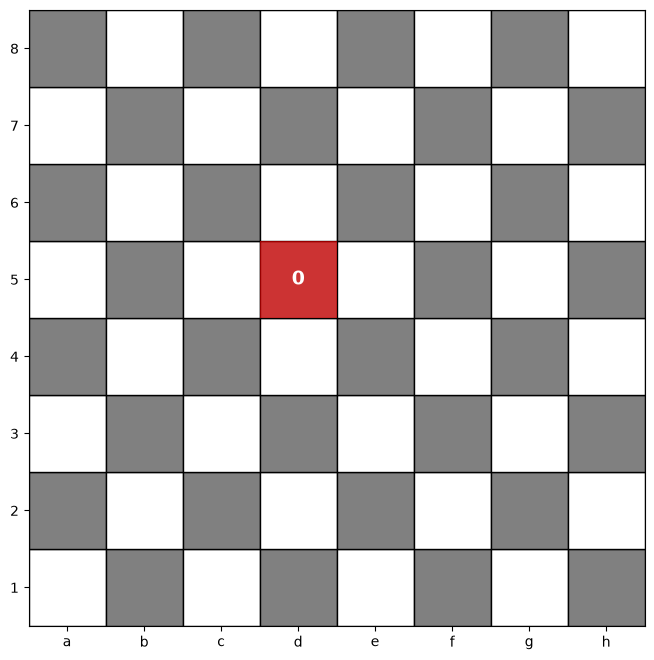

In [26]:
path = f"./images/{x}_{y}"
generator = GifGenerator(path)

generator.generate(
    output_path=f"./gif/evolucion_tablero_{x}_{y}.gif",
    duration=1500
)

¿Se tendrán resultados similares si el caballo inicia en la casilla $d5$? Justifique su respuesta.

- Se tienen los mismos resultados, se evidenció esto al realizar la ejecución del algoritmo iniciando en la posición $d5$.